# Homework 3: Pandas data analysis

### <p style="text-align: right;"> &#9989; **Siddak Marwaha** </p>

# __CMSE  201 &ndash; Spring 2022__

<img src="https://cmse.msu.edu/sites/_cmse/assets/Image/image002.jpg"
     alt="CMSE Logo"
     align="right" 
     height="100" 
     width="100" />



## Learning Goals

* Load data into notebooks using Pandas
* Determine the components of the data
* Make meaningful visual representations of the data
* Draw conclusions from statistical analysis 

___

## Assignment instructions

Work through the following assignment, making sure to follow all of the directions and answer all of the questions.

**This assignment is due at 11:59pm on Friday, Feb. 25th** 

It should be uploaded into D2L Homework #3.  Submission instructions can be found at the end of the notebook.

## Grading

- Academic integrity statement: 1 pt
- Part 0: Revisit plotting in HW2: 6 pts
- Part 1: Reading, Describing, and Cleaning the Data: 22 pts
- Part 2: Data analysis: 21 pts

**Total:** 50 pts


## Academic integrity statement (1 point)

In the markdown cell below, paste your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.

<font size=6 color="#009600">&#9998;</font> *I do not intend to cheat or plagiarize in this assignment. I confirm that I am submitting this as my own work and not that of anyone else.*

Before we read in the data and begin working with it, let's import the libraries that we would typically use for this task. You can always come back to this cell and import additional libraries that you need.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
%matplotlib inline

### Part 0: Revisit plotting in HW2 (6 total points)

In question 4 of HW2, we consider two equations that give the (x,y) points for values of k (ranging from 0 to 9000). When all 9000 points are plotted, you will see that it draws out a flower design.

$x(k) = \mathrm{cos}\Big(\frac{14 \pi k}{9000}\Big)\Big(1-\frac{3}{4}\mathrm{sin}\Big(\frac{20\pi k}{9000}\Big)-\frac{1}{4}\mathrm{cos}\Big(\frac{60 \pi k}{9000}\Big)\Big)$

$y(k) = \mathrm{sin}\Big(\frac{14 \pi k}{9000}\Big)\Big(1-\frac{3}{4}\mathrm{sin}\Big(\frac{20\pi k}{9000}\Big)-\frac{1}{4}\mathrm{cos}\Big(\frac{60 \pi k}{9000}\Big)\Big)$

The goal here is to revisit this problem, and achieve the same purpose by using numpy arrary and functions. Now the code will be much shorter. (Note: in this question, you are not allowed to use `list` and you no longer need to define `draw_flower_points` function.)

<font size=8 color="#009600">&#9998;</font> Do This - Write a piece of code to define `k` as a numpy array ranging from 0 to 9000 with 500 points. (2 points) Use `np.sin` and `np.cos` to define `x_k` and `y_k` as the corresponding numpy. (3 points) Then plot the final flower design. (1 point)


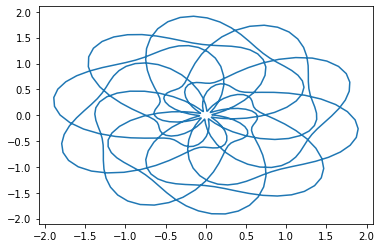

In [2]:
## your code here
k=np.linspace(0,9001,500)
x=[]
y=[]
for i in k:
    x_k=np.cos(14*np.pi*i/9000)*(1-(3/4)*(np.sin(20*np.pi*i/9000))-1/4*np.cos(60*np.pi*i/9000))
    y_k=np.sin(14*np.pi*i/9000)*(1-(3/4)*(np.sin(20*np.pi*i/9000))-1/4*np.cos(60*np.pi*i/9000))
    x.append(x_k)
    y.append(y_k)
plt.plot(x,y)

### Part 1: Reading, Describing, and Cleaning the Data (22 total points)


The United Nations compiles an annual publication called the [World Happiness Report](https://en.wikipedia.org/wiki/World_Happiness_Report) that ranks countries by the "happiness score" or "life ladder". These scores are based on a surveys of citizens of each country on a variety of factors such as:
* Gross Domestic Product (GDP) per capita
* Perceptions of social support
* Life expectancy
* Freedom of choice

[Data from the UN](https://worldhappiness.report/) is available from 2005-2019, which we have downloaded in a `.csv` format. The survey has changed over time, so that some factors and questions have been omitted. So some of the data is incomplete or missing.

### 1.1 Read the data (4 points)

<font size=8 color="#009600">&#9998;</font> Do This - Read in the survey data from `happiness_index.csv` into a DataFrame and print the `.head()` of the data, use `describe` to get a feel of this dataset.

In [3]:
## your code here
happiness_index=pd.read_csv('happiness_index.csv')
happiness_index.head()

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,...,GINI index (World Bank estimate),"GINI index (World Bank estimate), average 2000-2017, unbalanced panel","gini of household income reported in Gallup, by wp5-year","Most people can be trusted, Gallup","Most people can be trusted, WVS round 1981-1984","Most people can be trusted, WVS round 1989-1993","Most people can be trusted, WVS round 1994-1998","Most people can be trusted, WVS round 1999-2004","Most people can be trusted, WVS round 2005-2009","Most people can be trusted, WVS round 2010-2014"
0,Afghanistan,2008,3.723590,7.144916,0.450662,50.799999,0.718114,0.178993,0.881686,0.517637,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,2009,4.401778,7.314788,0.552308,51.200001,0.678896,0.201228,0.850035,0.583926,...,NaN,NaN,0.441906,0.286315,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,2010,4.758381,7.421525,0.539075,51.599998,0.600127,0.131578,0.706766,0.618265,...,NaN,NaN,0.327318,0.275833,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,2011,3.831719,7.394349,0.521104,51.919998,0.495901,0.173452,0.731109,0.611387,...,NaN,NaN,0.336764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,2012,3.782938,7.480296,0.520637,52.240002,0.530935,0.246943,0.775620,0.710385,...,NaN,NaN,0.344540,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
happiness_index.describe()

,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect,...,GINI index (World Bank estimate),"GINI index (World Bank estimate), average 2000-2017, unbalanced panel","gini of household income reported in Gallup, by wp5-year","Most people can be trusted, Gallup","Most people can be trusted, WVS round 1981-1984","Most people can be trusted, WVS round 1989-1993","Most people can be trusted, WVS round 1994-1998","Most people can be trusted, WVS round 1999-2004","Most people can be trusted, WVS round 2005-2009","Most people can be trusted, WVS round 2010-2014"
count,1848.000000,1848.000000,1819.000000,1835.000000,1796.000000,1817.000000,1765.000000,1745.000000,1827.000000,1833.000000,...,715.000000,1668.000000,1478.000000,180.000000,136.000000,237.000000,667.000000,529.000000,684.000000,724.000000
mean,2012.848485,5.445810,9.244531,0.811132,63.169525,0.738467,0.000109,0.749064,0.709623,0.267208,...,0.372032,0.385288,0.448997,0.226295,0.390234,0.283761,0.249783,0.268009,0.264345,0.237182
std,3.962437,1.118989,1.168422,0.118987,7.546524,0.143059,0.163220,0.186156,0.108186,0.085197,...,0.082268,0.080289,0.109078,0.119079,0.122932,0.113216,0.118586,0.145337,0.160412,0.157607
min,2005.000000,2.375092,6.456574,0.290184,32.299999,0.257534,-0.331775,0.035198,0.321690,0.083426,...,0.240000,0.249500,0.200969,0.066618,0.176535,0.066020,0.048720,0.075872,0.038242,0.031518
25%,2010.000000,4.623136,8.309359,0.748296,58.299999,0.643062,-0.117175,0.692724,0.623345,0.205950,...,0.309000,0.322333,0.369560,0.139773,0.290300,0.223553,0.176876,0.155833,0.143534,0.118725
50%,2013.000000,5.363165,9.407829,0.833975,65.099998,0.757478,-0.023724,0.803634,0.720842,0.255774,...,0.355000,0.368750,0.428156,0.198450,0.380174,0.292383,0.229924,0.232000,0.198380,0.193531
75%,2016.000000,6.268130,10.209482,0.904574,68.384998,0.852387,0.091154,0.873649,0.801082,0.317995,...,0.430000,0.432917,0.517146,0.281627,0.478149,0.341741,0.294242,0.385469,0.391370,0.335000
max,2019.000000,8.018934,11.728235,0.987343,77.099998,0.985178,0.679921,0.983276,0.943621,0.704590,...,0.634000,0.624000,0.961435,0.640332,0.571719,0.594595,0.647737,0.637185,0.737305,0.661757


### 1.2 Clean the data (8 total points)

#### 1.2.1 Remove and track excess data (2 points)

We need to remove the excess features that are not present in every year's data. 

<font size=8 color="#009600">&#9998;</font> Do This - Drop the columns that are not the following:
* Country name
* year
* Life Ladder
* Log GDP per capita
* Social support
* Healthy life expectancy at birth
* Freedom to make life choices
* Generosity
* Perceptions of corruption
* Positive affect
* Negative affect
* Confidence in national government
* Democratic Quality
* Delivery Quality

Make sure to make a list of the columns that you dropped. This is important if you need to report what you didn't consider in the model. Print the `.head()` of the DataFrame after dropping the unneeded columns.

In [5]:
## your code here
columns_dropped=[happiness_index.columns[14:]]
happiness_index1=happiness_index.drop(happiness_index.columns[14:], axis=1)
happiness_index1.head()

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect,Confidence in national government,Democratic Quality,Delivery Quality
0,Afghanistan,2008,3.723590,7.144916,0.450662,50.799999,0.718114,0.178993,0.881686,0.517637,0.258195,0.612072,-1.929690,-1.655084
1,Afghanistan,2009,4.401778,7.314788,0.552308,51.200001,0.678896,0.201228,0.850035,0.583926,0.237092,0.611545,-2.044093,-1.635025
2,Afghanistan,2010,4.758381,7.421525,0.539075,51.599998,0.600127,0.131578,0.706766,0.618265,0.275324,0.299357,-1.991810,-1.617176
3,Afghanistan,2011,3.831719,7.394349,0.521104,51.919998,0.495901,0.173452,0.731109,0.611387,0.267175,0.307386,-1.919018,-1.616221
4,Afghanistan,2012,3.782938,7.480296,0.520637,52.240002,0.530935,0.246943,0.775620,0.710385,0.267919,0.435440,-1.842996,-1.404078


#### 1.2.2 Focus on the 2018 data (3 points)

Your data should include scores for a variety of years (2005-2019) for each country. Let's focus on a single year: 2018. 

<font size=8 color="#009600">&#9998;</font> Do This - Use mask to filter your data to focus only on the latest available data from 2018. Print the `.head()` of that DataFrame.

In [6]:
## your code here
vals=happiness_index['year']
mask=(vals==2018)
happiness_index2018=happiness_index1[mask]
happiness_index2018.head()

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect,Confidence in national government,Democratic Quality,Delivery Quality
10,Afghanistan,2018,2.694303,7.458603,0.507516,52.599998,0.373536,-0.082319,0.927606,0.424125,0.404904,0.364666,-1.870725,-1.438761
22,Albania,2018,5.004403,9.417863,0.683592,68.699997,0.824212,0.008337,0.899129,0.713300,0.318997,0.435338,0.294235,-0.129403
30,Algeria,2018,5.043086,9.538646,0.798651,65.900002,0.583381,-0.167403,0.758704,0.591043,0.292946,NaN,-0.887384,-0.779863
48,Argentina,2018,5.792797,9.813678,0.899912,68.800003,0.845895,-0.203153,0.855255,0.820310,0.320502,0.261352,0.292617,-0.135139
62,Armenia,2018,5.062449,9.124537,0.814449,66.900002,0.807644,-0.146650,0.676826,0.581488,0.454840,0.670828,-0.266119,-0.063556


#### 1.2.3 Missing data (3 points)

Not all the countries have reported values for every feature. You should check if any countries have missing data. We could impute these missing data in a variety of ways, but instead to make our work a little simpler, we will simply drop a country if it has any missing data.  

<font size=8 color="#009600">&#9998;</font> Do This - Drop any country from the data that is missing data.

In [7]:
## your code here
happiness_index2018=happiness_index2018.dropna()
happiness_index2018

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect,Confidence in national government,Democratic Quality,Delivery Quality
10,Afghanistan,2018,2.694303,7.458603,0.507516,52.599998,0.373536,-0.082319,0.927606,0.424125,0.404904,0.364666,-1.870725,-1.438761
22,Albania,2018,5.004403,9.417863,0.683592,68.699997,0.824212,0.008337,0.899129,0.713300,0.318997,0.435338,0.294235,-0.129403
48,Argentina,2018,5.792797,9.813678,0.899912,68.800003,0.845895,-0.203153,0.855255,0.820310,0.320502,0.261352,0.292617,-0.135139
62,Armenia,2018,5.062449,9.124537,0.814449,66.900002,0.807644,-0.146650,0.676826,0.581488,0.454840,0.670828,-0.266119,-0.063556
74,Australia,2018,7.176993,10.724133,0.940137,73.599998,0.916028,0.143235,0.404647,0.759019,0.187456,0.468837,1.202361,1.761815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1766,Uruguay,2018,6.371715,9.948277,0.917316,69.000000,0.876211,-0.103306,0.682916,0.876920,0.274946,0.361706,1.129429,0.730533
1779,Uzbekistan,2018,6.205460,8.738785,0.920821,65.099998,0.969898,0.316426,0.520360,0.825422,0.208660,0.969356,-0.949705,-0.948074
1819,Yemen,2018,3.057514,7.734108,0.789422,56.700001,0.552726,-0.148377,0.792587,0.461114,0.314870,0.308151,-2.376622,-1.802231
1832,Zambia,2018,4.041488,8.228971,0.717720,55.299999,0.790626,0.037525,0.810731,0.702698,0.350963,0.606715,-0.089234,-0.500724


### 1.3 Describe the data (10 points)

Now that you have a cleaned data set, let's look into the data. We can start that by describing the data and making histograms of it. 

<font size=8 color="#009600">&#9998;</font> Do This - Focusing on the data collected in the survey (i.e., not the country name or year), *describe* the data by using the `describe` function in pandas. (2 points)

In [8]:
## your code here
happiness_index2018.describe()

,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect,Confidence in national government,Democratic Quality,Delivery Quality
count,121.0,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000
mean,2018.0,5.539629,9.301184,0.813747,64.520548,0.782520,-0.021389,0.732900,0.709785,0.293109,0.501551,-0.023181,0.064975
std,0.0,1.123867,1.178485,0.115870,7.015459,0.118026,0.161363,0.191199,0.109544,0.089140,0.200848,0.847969,0.963460
min,2018.0,2.694303,6.837319,0.503544,48.200001,0.373536,-0.331775,0.096563,0.424125,0.106871,0.079710,-2.376622,-1.802231
25%,2018.0,4.769377,8.263374,0.739355,58.500000,0.716484,-0.137043,0.692341,0.642437,0.217146,0.343467,-0.625558,-0.682249
50%,2018.0,5.513500,9.497988,0.845803,66.400002,0.797057,-0.039868,0.793758,0.735343,0.282063,0.476145,-0.102986,-0.152066
75%,2018.0,6.249419,10.264216,0.909807,69.599998,0.874548,0.070828,0.855255,0.793368,0.357458,0.632478,0.678356,0.738143
max,2018.0,7.858107,11.448219,0.965962,76.800003,0.969898,0.502898,0.952014,0.883581,0.543836,0.988120,1.582492,2.095614


<font size=8 color="#009600">&#9998;</font> Do This - We can use numpy functions to verify what we have obtained in the description in the previous part. Define a Numpy array to be the same as the column of data corresponding to the feature 'Life Ladder'. Use Numpy functions to compute the mean and the standard deviation of this array. Does it agree with what you had from the previous question? (4 points)

In [9]:
## your code here
life_ladder=np.array(happiness_index2018['Life Ladder'])
print('Mean is: ', life_ladder.mean())
print ('Standard Deviation is: ', life_ladder.std()) 
#The standard deviation computed through numpy is at an approx 0.004 difference from standard deviation shown in describe funtion

Mean is:  5.539629473190082
Standard Deviation is:  1.119213392470201


<font size=8 color="#009600">&#9998;</font> Do This -Make histograms describing the distributions of all the features. (4 points)

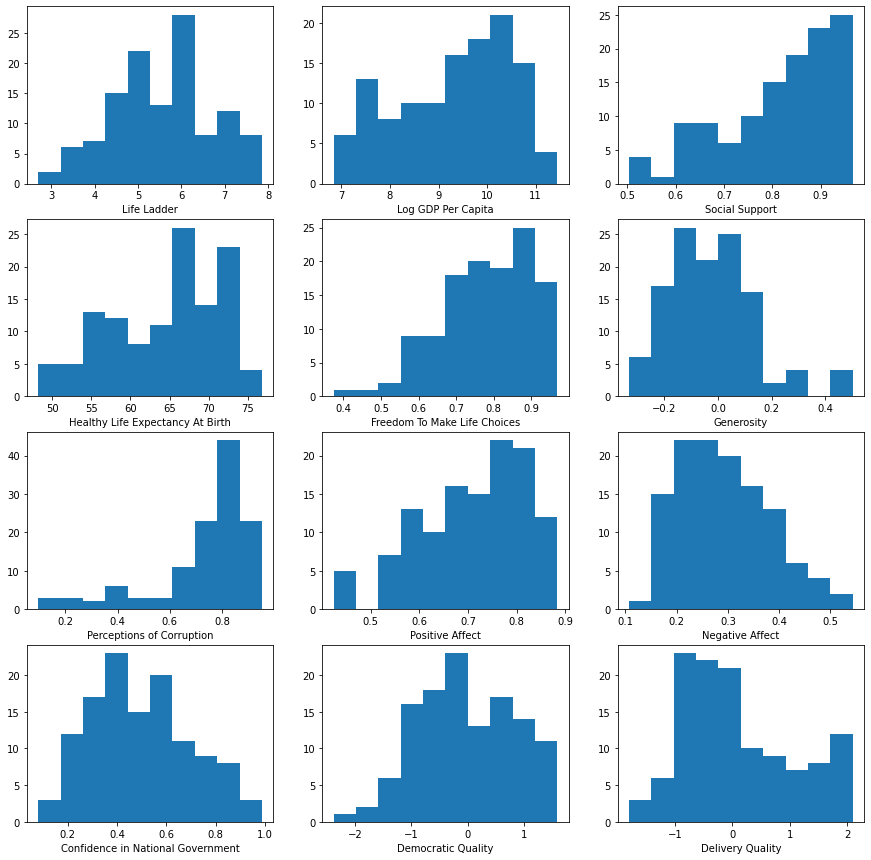

In [10]:
## your code here
plt.figure(figsize=(15,15))
plt.subplot(4,3,1)
plt.hist(happiness_index2018['Life Ladder'])
plt.xlabel('Life Ladder')
plt.subplot(4,3,2)
plt.hist(happiness_index2018['Log GDP per capita'])
plt.xlabel('Log GDP Per Capita')
plt.subplot(4,3,3)
plt.hist(happiness_index2018['Social support'])
plt.xlabel('Social Support')
plt.subplot(4,3,4)
plt.hist(happiness_index2018['Healthy life expectancy at birth'])
plt.xlabel('Healthy Life Expectancy At Birth')
plt.subplot(4,3,5)
plt.hist(happiness_index2018['Freedom to make life choices'])
plt.xlabel('Freedom To Make Life Choices')
plt.subplot(4,3,6)
plt.hist(happiness_index2018['Generosity'])
plt.xlabel('Generosity')
plt.subplot(4,3,7)
plt.hist(happiness_index2018['Perceptions of corruption'])
plt.xlabel('Perceptions of Corruption')
plt.subplot(4,3,8)
plt.hist(happiness_index2018['Positive affect'])
plt.xlabel('Positive Affect')
plt.subplot(4,3,9)
plt.hist(happiness_index2018['Negative affect'])
plt.xlabel('Negative Affect')
plt.subplot(4,3,10)
plt.hist(happiness_index2018['Confidence in national government'])
plt.xlabel('Confidence in National Government')
plt.subplot(4,3,11)
plt.hist(happiness_index2018['Democratic Quality'])
plt.xlabel('Democratic Quality')
plt.subplot(4,3,12)
plt.hist(happiness_index2018['Delivery Quality'])
plt.xlabel('Delivery Quality')

plt.show()

## Part 2: Data analysis (21 total points)

Now  we will analyze the cleaned dataset.

### 2.1 The ranking (12 points)

The rankings of national happiness are based on a Cantril ladder survey. Nationally representative samples of respondents are asked to think of a ladder, with the best possible life for them being a 10, and the worst possible life being a 0.  This is represented by 'Life Ladder' in the dataset.


<font size=8 color="#009600">&#9998;</font> Do This - Reorder the dataframe   according to descending values of the 'Life Ladder' score using `sort_values` (Refer to  (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html#pandas.DataFrame.sort_values). Which are the top 3 happiest  countries? (4 points)

In [11]:
## your code here
happiness_index_sorted=happiness_index2018.sort_values(['Life Ladder'],ascending=False)
happiness_index_sorted.head(3) #Top 3 happiest countries are Finland, Denmark and Switzerland

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect,Confidence in national government,Democratic Quality,Delivery Quality
531,Finland,2018,7.858107,10.640223,0.962155,71.900002,0.937807,-0.126522,0.198605,0.781546,0.181781,0.555102,1.268654,2.007365
438,Denmark,2018,7.648786,10.772796,0.958219,72.400002,0.935438,0.020070,0.150607,0.821423,0.206053,0.632478,1.285432,1.882464
1574,Switzerland,2018,7.508587,10.985619,0.930291,74.099998,0.926415,0.101783,0.301260,0.792226,0.191520,0.849979,1.480642,1.940240


<font size=8 color="#009600">&#9998;</font> Do This -  Replace the index of the sorted dataframe to be the ranking of the ranking of the country. (4 points)

In [12]:
## your code here
happiness_index_sorted.index=np.arange(1,122)
happiness_index_sorted

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect,Confidence in national government,Democratic Quality,Delivery Quality
1,Finland,2018,7.858107,10.640223,0.962155,71.900002,0.937807,-0.126522,0.198605,0.781546,0.181781,0.555102,1.268654,2.007365
2,Denmark,2018,7.648786,10.772796,0.958219,72.400002,0.935438,0.020070,0.150607,0.821423,0.206053,0.632478,1.285432,1.882464
3,Switzerland,2018,7.508587,10.985619,0.930291,74.099998,0.926415,0.101783,0.301260,0.792226,0.191520,0.849979,1.480642,1.940240
4,Netherlands,2018,7.463097,10.815511,0.939443,72.300003,0.919985,0.160900,0.370558,0.861977,0.204794,0.656541,1.232369,1.923523
5,Norway,2018,7.444262,11.088910,0.965962,73.199997,0.960429,0.081801,0.268201,0.827414,0.211862,0.679503,1.443176,1.925274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,Botswana,2018,3.461366,9.712220,0.794936,58.900002,0.817621,-0.257587,0.806945,0.729643,0.267084,0.718788,0.726948,0.501335
118,Tanzania,2018,3.445023,7.969772,0.675330,57.500000,0.807142,0.139509,0.611534,0.762089,0.221005,0.914648,-0.461791,-0.593028
119,Malawi,2018,3.334634,7.058997,0.527843,57.599998,0.798915,0.060292,0.765964,0.586300,0.364894,0.572985,-0.191557,-0.630798
120,Yemen,2018,3.057514,7.734108,0.789422,56.700001,0.552726,-0.148377,0.792587,0.461114,0.314870,0.308151,-2.376622,-1.802231


<font size=8 color="#009600">&#9998;</font> Do this - Use mask to find the United States in this ranking. What's the ranking of the U.S.? (4 points)

In [13]:
## your code here
vals=happiness_index_sorted['Country name']
mask=(vals=='United States')
vals[mask] #U.S. Ranking is 20.

20    United States
Name: Country name, dtype: object

### 2.2 Determining which features will matter (9 points)

We want to understand what variables matters for people's happiness. We will do this by starting the correlation of the features with `Life Ladder`.

<font size=8 color="#009600">&#9998;</font> Do this - Make   `scatter` plots of `Life Ladder` vs. all other features. (5 points)  

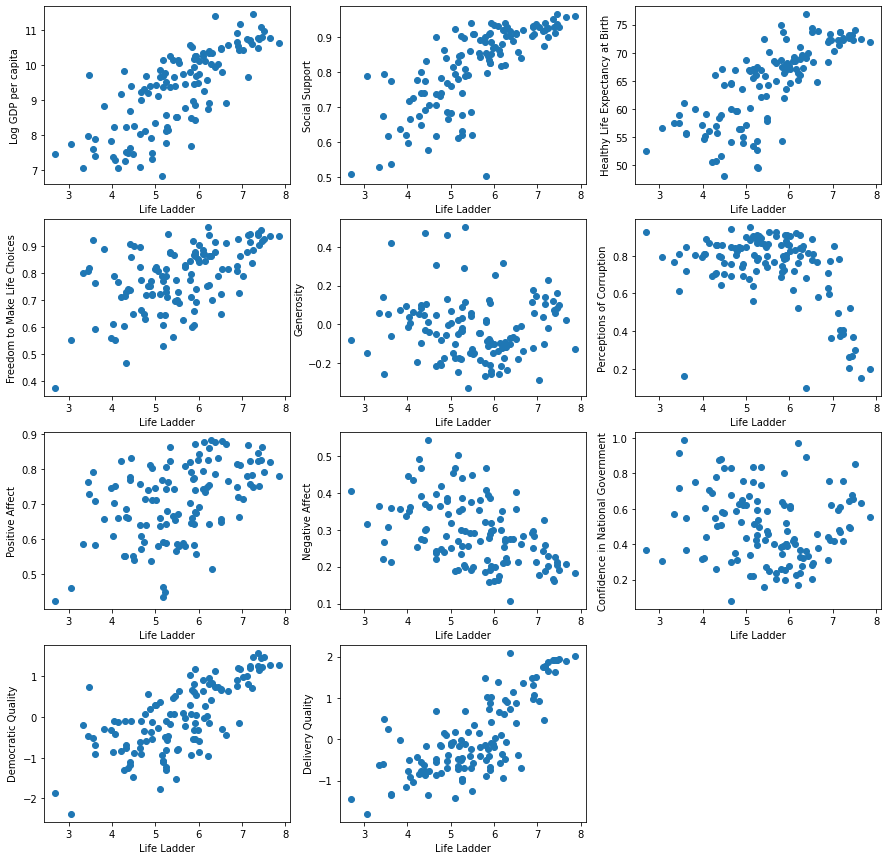

In [14]:
## your code here
plt.figure(figsize=(15,15))
plt.subplot(4,3,1)
plt.scatter(happiness_index_sorted['Life Ladder'], happiness_index_sorted['Log GDP per capita'])
plt.xlabel('Life Ladder')
plt.ylabel('Log GDP per capita')
plt.subplot(4,3,2)
plt.scatter(happiness_index_sorted['Life Ladder'], happiness_index_sorted['Social support'])
plt.xlabel('Life Ladder')
plt.ylabel('Social Support')
plt.subplot(4,3,3)
plt.scatter(happiness_index_sorted['Life Ladder'], happiness_index_sorted['Healthy life expectancy at birth'])
plt.xlabel('Life Ladder')
plt.ylabel('Healthy Life Expectancy at Birth')
plt.subplot(4,3,4)
plt.scatter(happiness_index_sorted['Life Ladder'], happiness_index_sorted['Freedom to make life choices'])
plt.xlabel('Life Ladder')
plt.ylabel('Freedom to Make Life Choices')
plt.subplot(4,3,5)
plt.scatter(happiness_index_sorted['Life Ladder'], happiness_index_sorted['Generosity'])
plt.xlabel('Life Ladder')
plt.ylabel('Generosity')
plt.subplot(4,3,6)
plt.scatter(happiness_index_sorted['Life Ladder'], happiness_index_sorted['Perceptions of corruption'])
plt.xlabel('Life Ladder')
plt.ylabel('Perceptions of Corruption')
plt.subplot(4,3,7)
plt.scatter(happiness_index_sorted['Life Ladder'], happiness_index_sorted['Positive affect'])
plt.xlabel('Life Ladder')
plt.ylabel('Positive Affect')
plt.subplot(4,3,8)
plt.scatter(happiness_index_sorted['Life Ladder'], happiness_index_sorted['Negative affect'])
plt.xlabel('Life Ladder')
plt.ylabel('Negative Affect')
plt.subplot(4,3,9)
plt.scatter(happiness_index_sorted['Life Ladder'], happiness_index_sorted['Confidence in national government'])
plt.xlabel('Life Ladder')
plt.ylabel('Confidence in National Government')
plt.subplot(4,3,10)
plt.scatter(happiness_index_sorted['Life Ladder'], happiness_index_sorted['Democratic Quality'])
plt.xlabel('Life Ladder')
plt.ylabel('Democratic Quality')
plt.subplot(4,3,11)
plt.scatter(happiness_index_sorted['Life Ladder'], happiness_index_sorted['Delivery Quality'])
plt.xlabel('Life Ladder')
plt.ylabel('Delivery Quality')

plt.show()

<font size=8 color="#009600">&#9998;</font> Do this -  Look at your plots, for each feature, is it correlated to `Life Ladder`? If so, is it positively or negatively correlated? Explain your reasoning (4 points)

<font size=6 color="#009600">&#9998;</font> 
*Log GDP Per Capita: Positively Correlated because as y axis value increases, Life Ladder value increases.*

*Social Support: Positively Correlated because as y axis value increases, Life Ladder value increases*

*Healthy Life Expectancy at Birth: Positively Correlated because as y axis value increases, Life Ladder value increases*

*Freedom to Make Life Choices: Positively Correlated because as y axis value increases, Life Ladder value increases but seems to be a little less correlated than others*

*Generosity: It does not seem to be correlated.*

*Perceptions of Corruption: Negatively Correlated because as y axis value decreases, Life Ladder value increases*

*Positive Affect: Positively Correlated because as y axis value increases, Life Ladder value increases but seems to be a little less correlated than others.*

*Negative Affect: Negatively Correlated because as y axis value decreases, Life Ladder value increases  but seems to be a little less correlated than others*

*Confidence in National Government: It does not seem to be correlated.*

*Democratic Quality: Positively Correlated because as y axis value increases, Life Ladder value increases*

*Delivery Quality: Positively Correlated because as y axis value increases, Life Ladder value increases*


---

### Congratulations, you're done!

Submit this assignment by uploading it to the course Desire2Learn web page.  Go to the "Homework Assignments" section, find the submission folder link for Homework #3, and upload it there.

&#169; Copyright Michigan State University Board of Trustees